# FAPE, Law School Admissions Fairness Intervention: ThresholdOptimizer

Phase 4, fairness intervention (Stage 3 of the framework) in the education/legal domain. The script applies Fairlearn's ThresholdOptimizer post-processing to the Law School baseline models under the demographic parity and equalized odds constraints and compares baseline and constrained models. Race (`racetxt`, 0 = minority, 1 = white) is the constrained attribute, and sex (`male`) gets a demographic parity check after the race constraint; both columns stay among the model's features. The target is `pass_bar`, with a 90.2% positive rate; that imbalance inflates F1, so AUC is the primary metric. The minority group is 6.4% of the data (n=1,201, about 240 in the test split), so its rates carry more sampling noise.

Code: `src/stage2_lawschool_threshold.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from stage2_lawschool_threshold import run_stage2

run_stage2();  # returns (baseline, dp_results, eo_results); the semicolon keeps Jupyter from echoing it

FAPE Phase 4, Law School Fairness Intervention: ThresholdOptimizer
Loading Law School Admissions dataset via FairGround...
  OK: law_school_admissions: 18,692 rows | 11 features | sensitive: ['racetxt', 'male'] | positive rate: 0.902

  n=18,692 | pos_rate=90.2% | minority_n=1,201 (6.4%)
  Note: AUC primary metric, F1 inflated by 90.2% positive rate
  DIR is minority over majority predicted bar-passage rate; 0.8 is the four-fifths convention
  Note: ThresholdOptimizer.predict is seeded with random_state=42, so runs are identical

--- Baseline Results (unconstrained models) ---


  LogisticRegression        AUC=0.872 DP_diff=0.329 EO_diff=0.543


  GradientBoosting          AUC=0.878 DP_diff=0.351 EO_diff=0.528

--- ThresholdOptimizer, Demographic Parity Constraint ---


  LogisticRegression        DP_diff=0.011 EO_diff=0.265 Acc=0.765 DP_improve=+0.318


  GradientBoosting          DP_diff=0.030 EO_diff=0.242 Acc=0.754 DP_improve=+0.320

--- ThresholdOptimizer, Equalized Odds Constraint ---


  LogisticRegression        DP_diff=0.111 EO_diff=0.060 Acc=0.684 EO_improve=+0.483


  GradientBoosting          DP_diff=0.163 EO_diff=0.007 Acc=0.757 EO_improve=+0.521

--- Fairness Improvement Summary, Race (Demographic Parity) ---
  LogisticRegression        DP before=0.329 after=0.011 improve=+0.318
  GradientBoosting          DP before=0.351 after=0.030 improve=+0.320

--- Fairness Improvement Summary, Race (Equalized Odds) ---
  LogisticRegression        EO before=0.543 after=0.060 improve=+0.483
  GradientBoosting          EO before=0.528 after=0.007 improve=+0.521

--- Sex Fairness, ThresholdOptimizer (Demographic Parity) ---
  LogisticRegression        Sex DP_diff=0.014
  GradientBoosting          Sex DP_diff=0.008

--- Race Prediction Rates, GB Before vs After DP Constraint ---
  Minority   before=0.631 after=0.678
  White      before=0.981 after=0.708

--- Key Findings ---
  Minority/majority DIR is computed below, before and after the DP constraint
  Minority group: 6.4% of data, 233 test records
  Sex DP gap after the race DP constraint: 0.008 to 0.014
  T


--- Disparate Impact Ratio, Before vs After DP Constraint ---
  LogisticRegression        DIR before=0.666 after=0.985 0.8 convention: at or above
  GradientBoosting          DIR before=0.643 after=0.957 0.8 convention: at or above

--- Intersectional Analysis, Race x Sex (GB DP Constraint) ---
  Minority Female   n=152 before=0.645 after=0.697 change=+0.053
  Minority Male     n=81 before=0.605 after=0.642 change=+0.037
  White Female   n=1,518 before=0.977 after=0.712 change=-0.265
  White Male     n=1,988 before=0.985 after=0.705 change=-0.280



--- Law School intervention complete ---
  ThresholdOptimizer applied, racial gap targeted
  GradientBoosting minority/majority DIR before the constraint: 0.643
  Stage 4 drift monitoring for these models: src/fairness_drift_monitor.py


## 1. Accuracy and DPD, baseline and constrained

Accuracy and race demographic parity difference for each model at baseline and under each constraint.

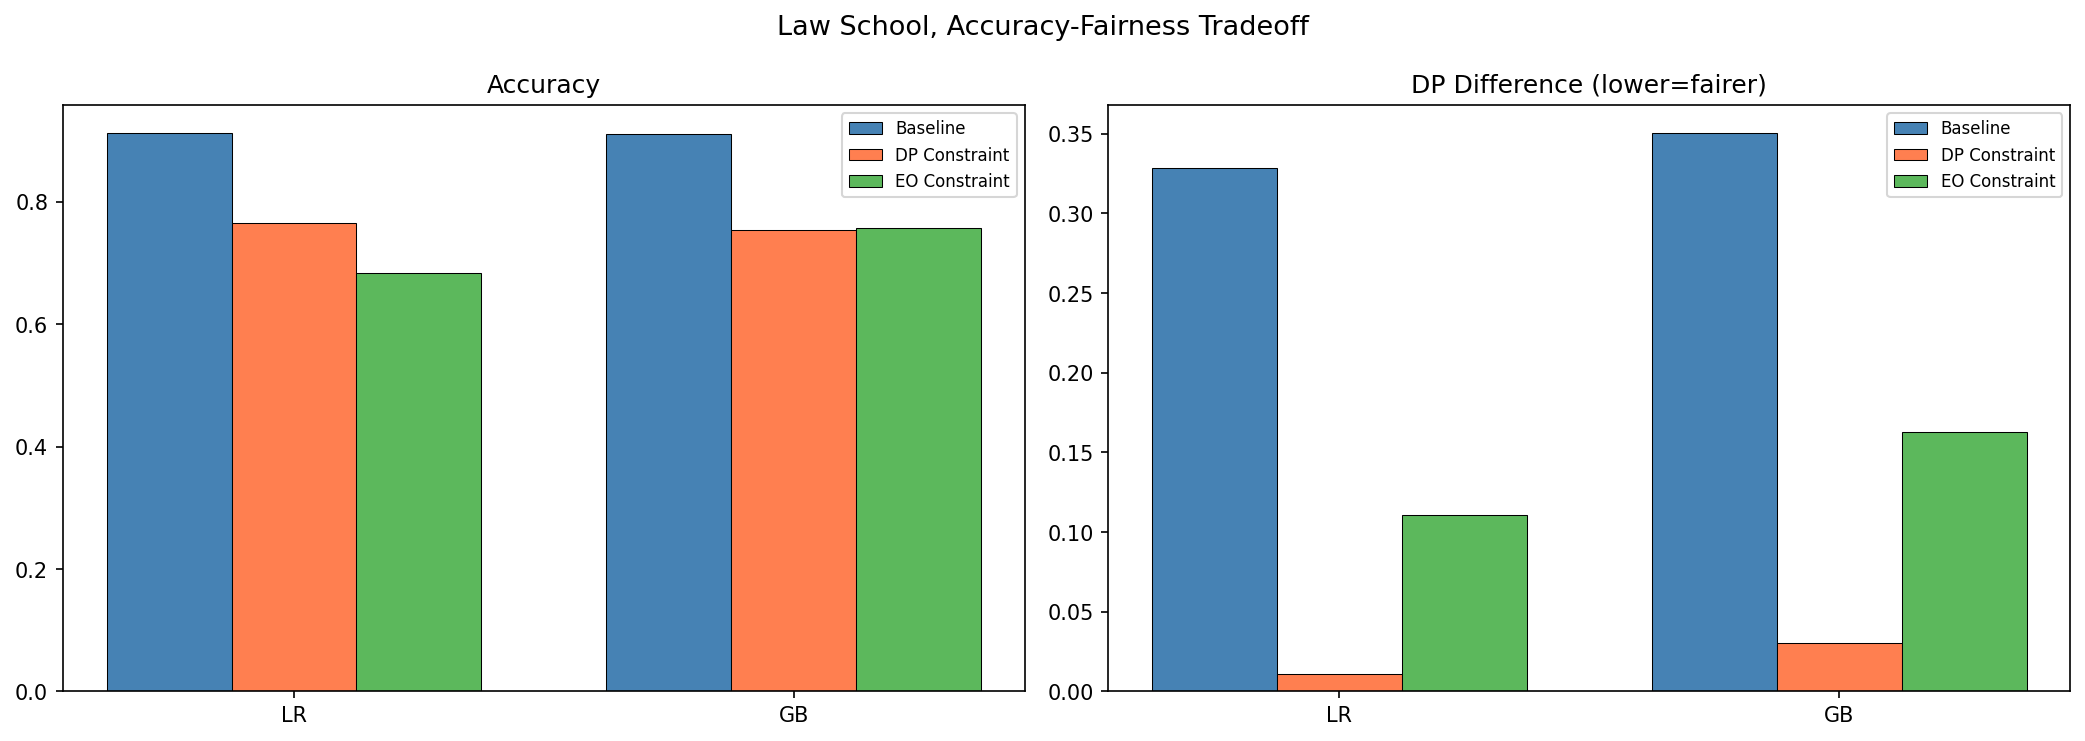

In [3]:
display(Image('figures/stage2/lawschool_accuracy_fairness_tradeoff.png'))

## 2. Fairness improvement by constraint

Reduction in race DPD under the demographic parity constraint and in race EOD under the equalized odds constraint, for each model.

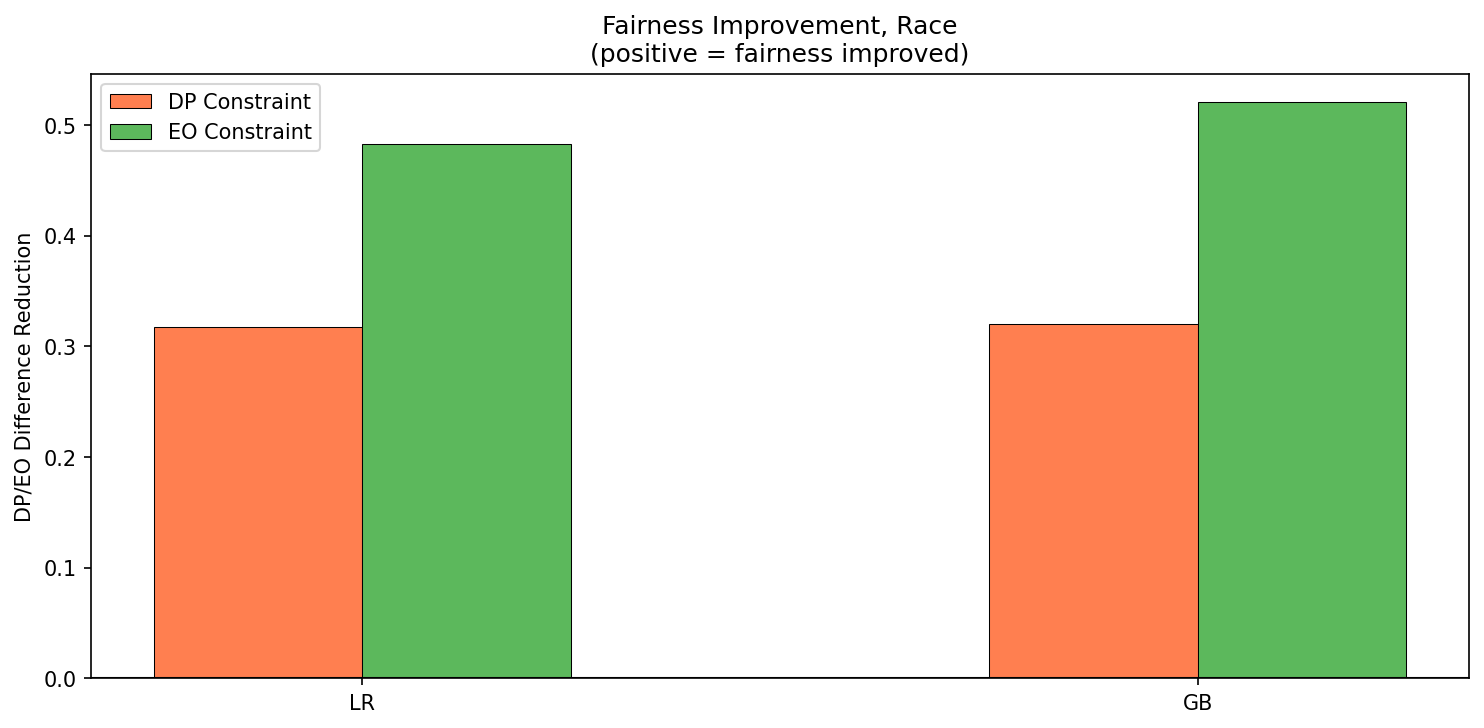

In [4]:
display(Image('figures/stage2/lawschool_fairness_improvement.png'))

## 3. Accuracy cost against fairness gain

Each model's accuracy cost plotted against its fairness gain under each constraint.

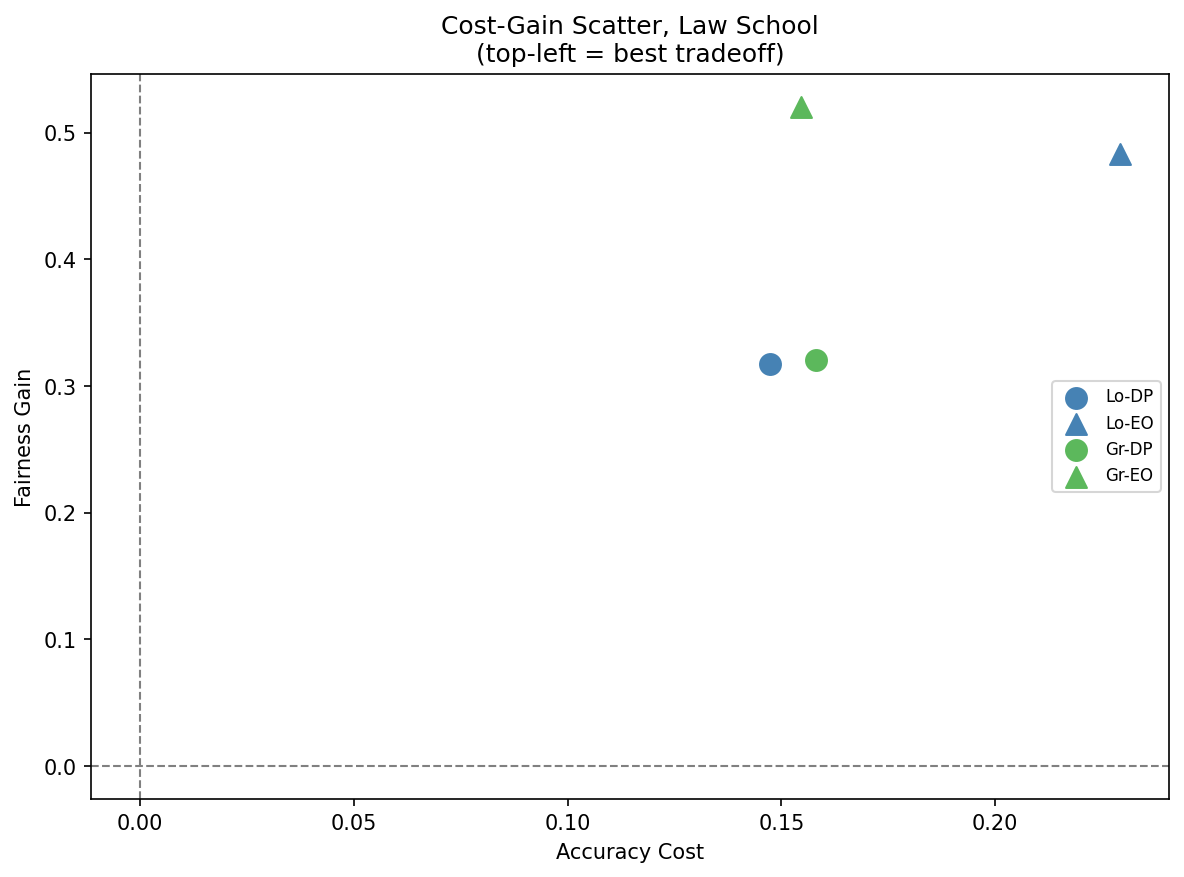

In [5]:
display(Image('figures/stage2/lawschool_cost_gain_scatter.png'))

## 4. Sex DPD

Sex demographic parity difference for each model at baseline and after the race demographic parity constraint.

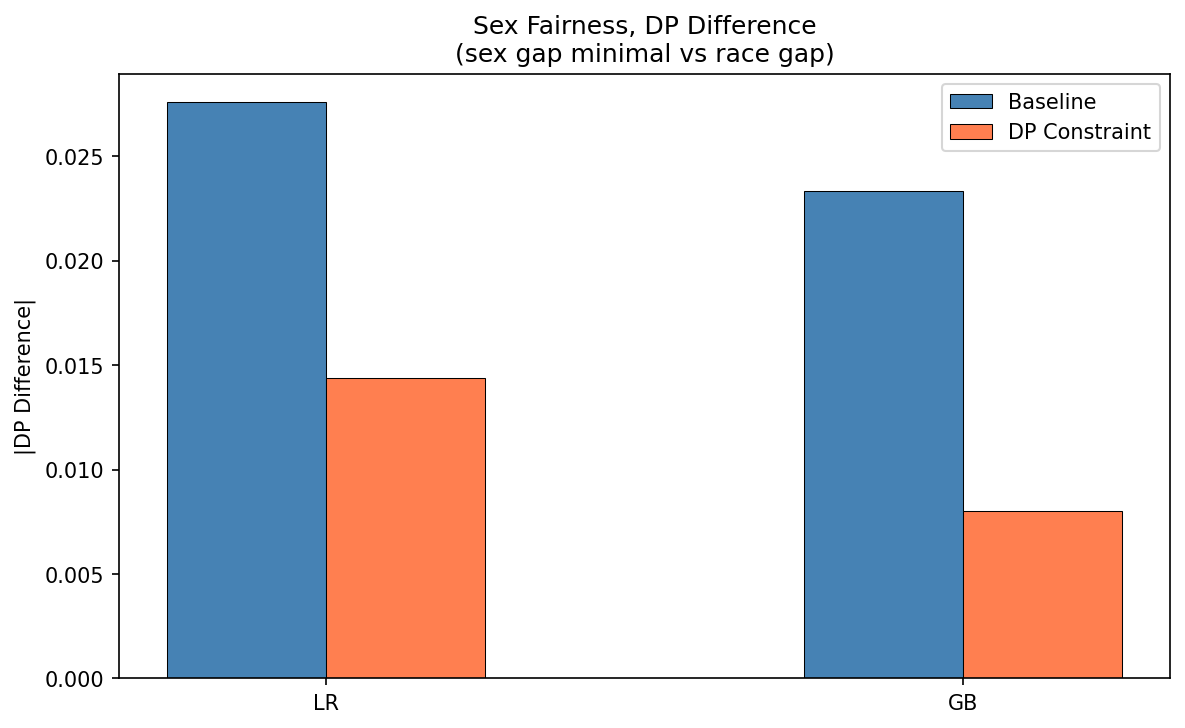

In [6]:
display(Image('figures/stage2/lawschool_sex_fairness.png'))

## 5. F1 comparison

F1 score for each model at baseline and under the demographic parity constraint.

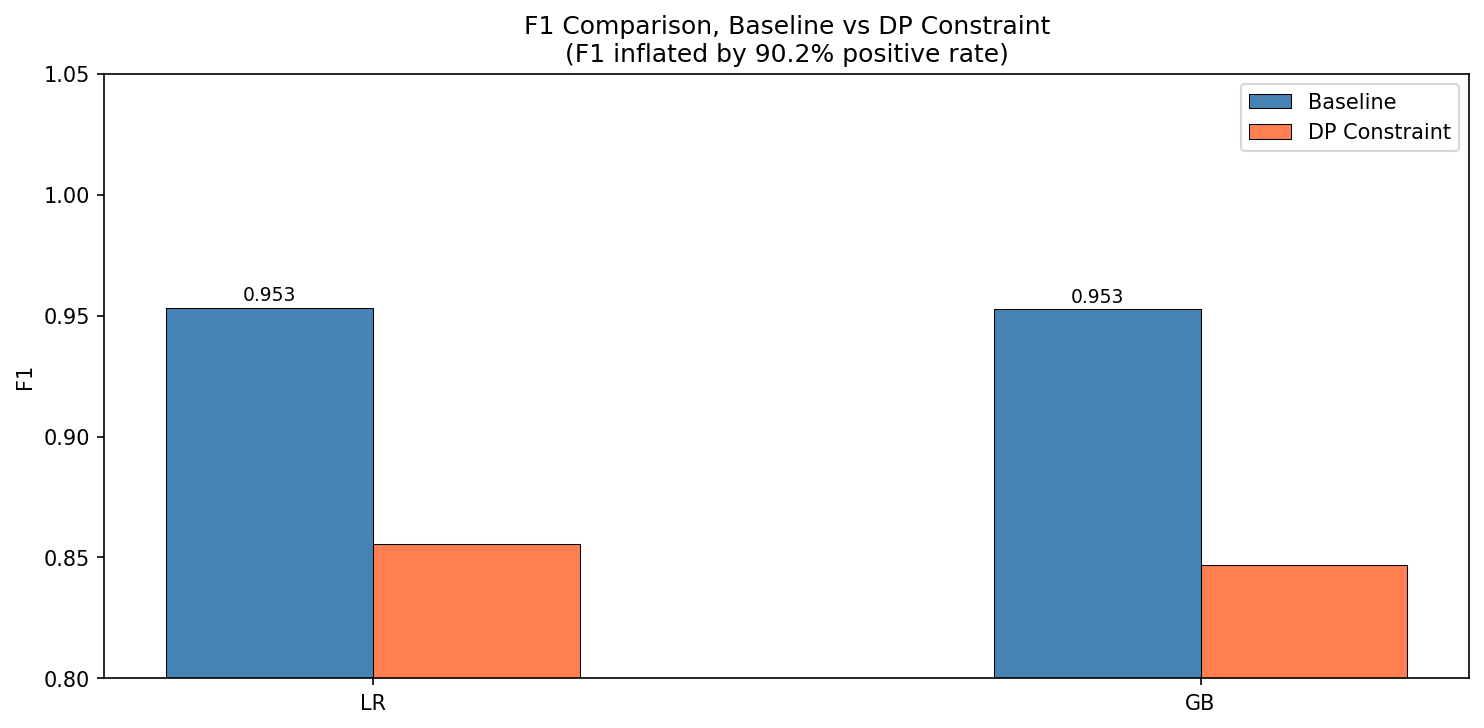

In [7]:
display(Image('figures/stage2/lawschool_f1_comparison.png'))

## 6. Predicted pass rates by race

Gradient boosting's predicted bar-passage rate for the minority and white groups, before and after the demographic parity constraint.

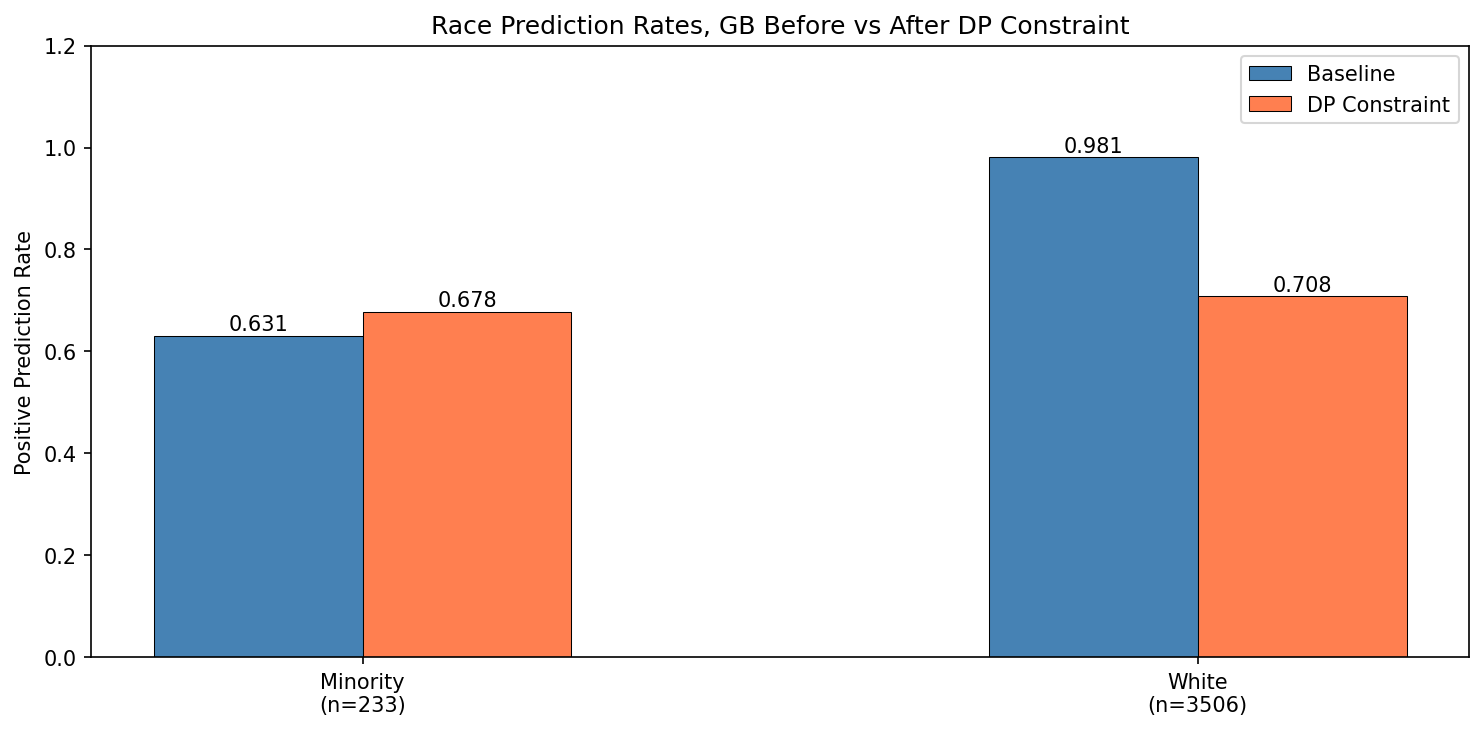

In [8]:
display(Image('figures/stage2/lawschool_race_prediction_rates.png'))

## 7. FPR and FNR by race

Gradient boosting's false positive and false negative rates by race, at baseline and under the demographic parity constraint.

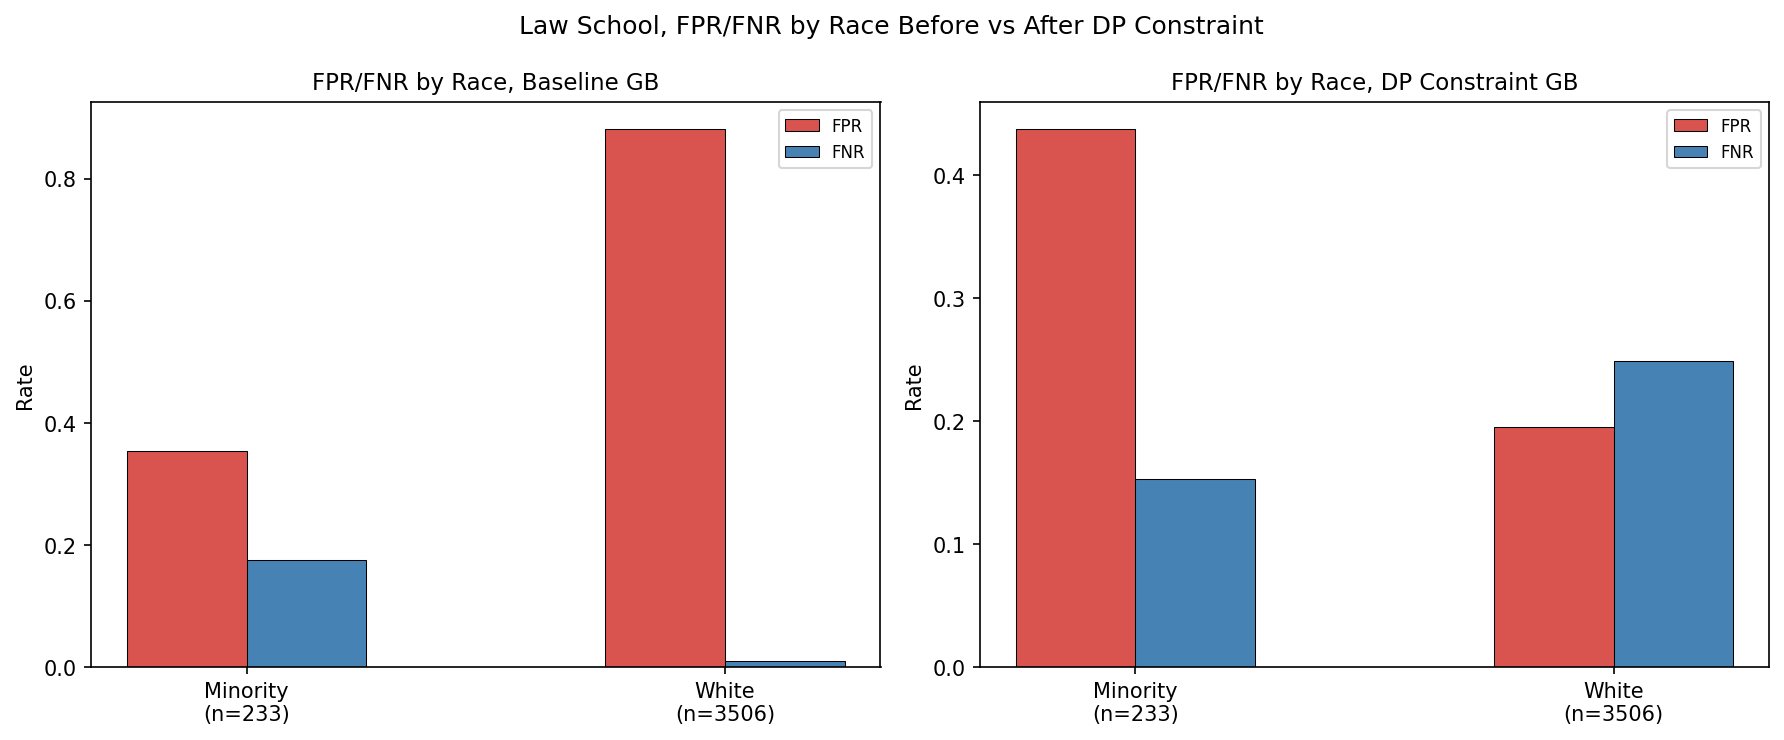

In [9]:
display(Image('figures/stage2/lawschool_fpr_fnr_by_race.png'))

## 8. Disparate impact ratio before and after the demographic parity constraint

Minority-to-majority ratio of predicted bar-passage rates for each model, before and after the demographic parity constraint.

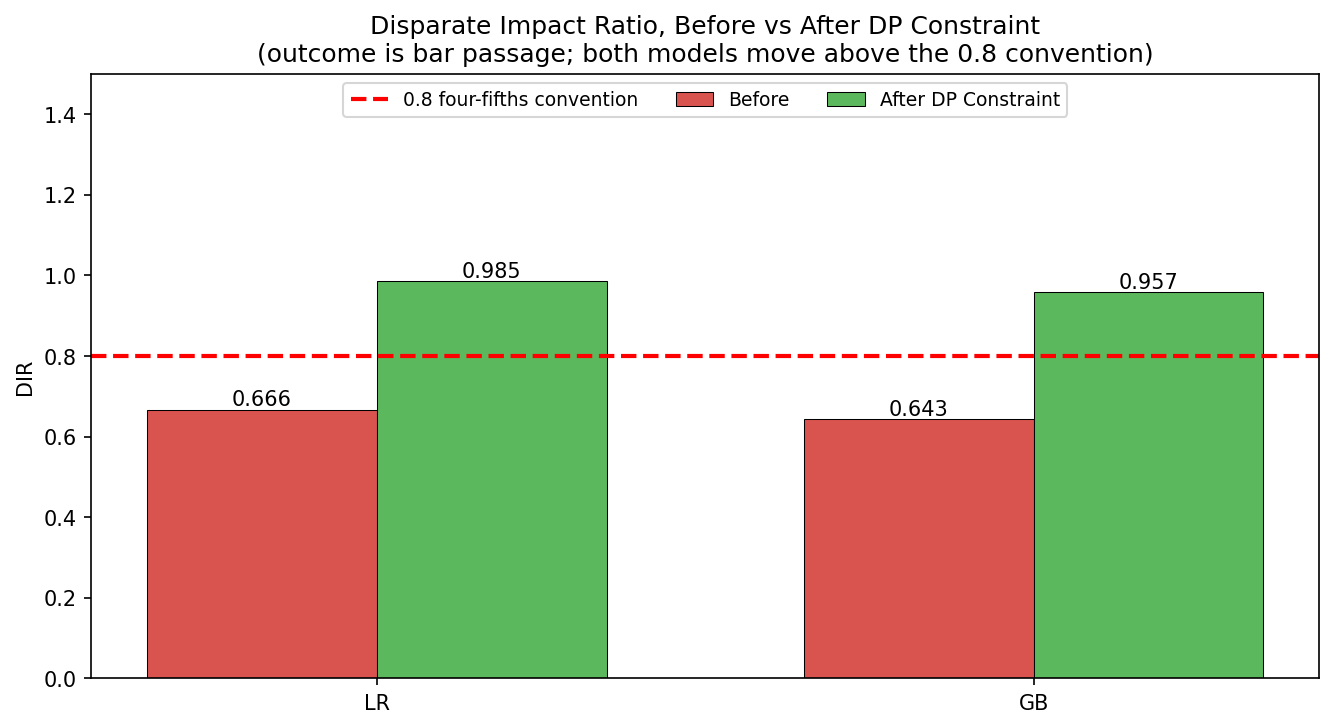

In [10]:
display(Image('figures/stage2/lawschool_dir_before_after.png'))

## 9. Race by sex

Gradient boosting's predicted pass rate for each race and sex group, before and after the demographic parity constraint.

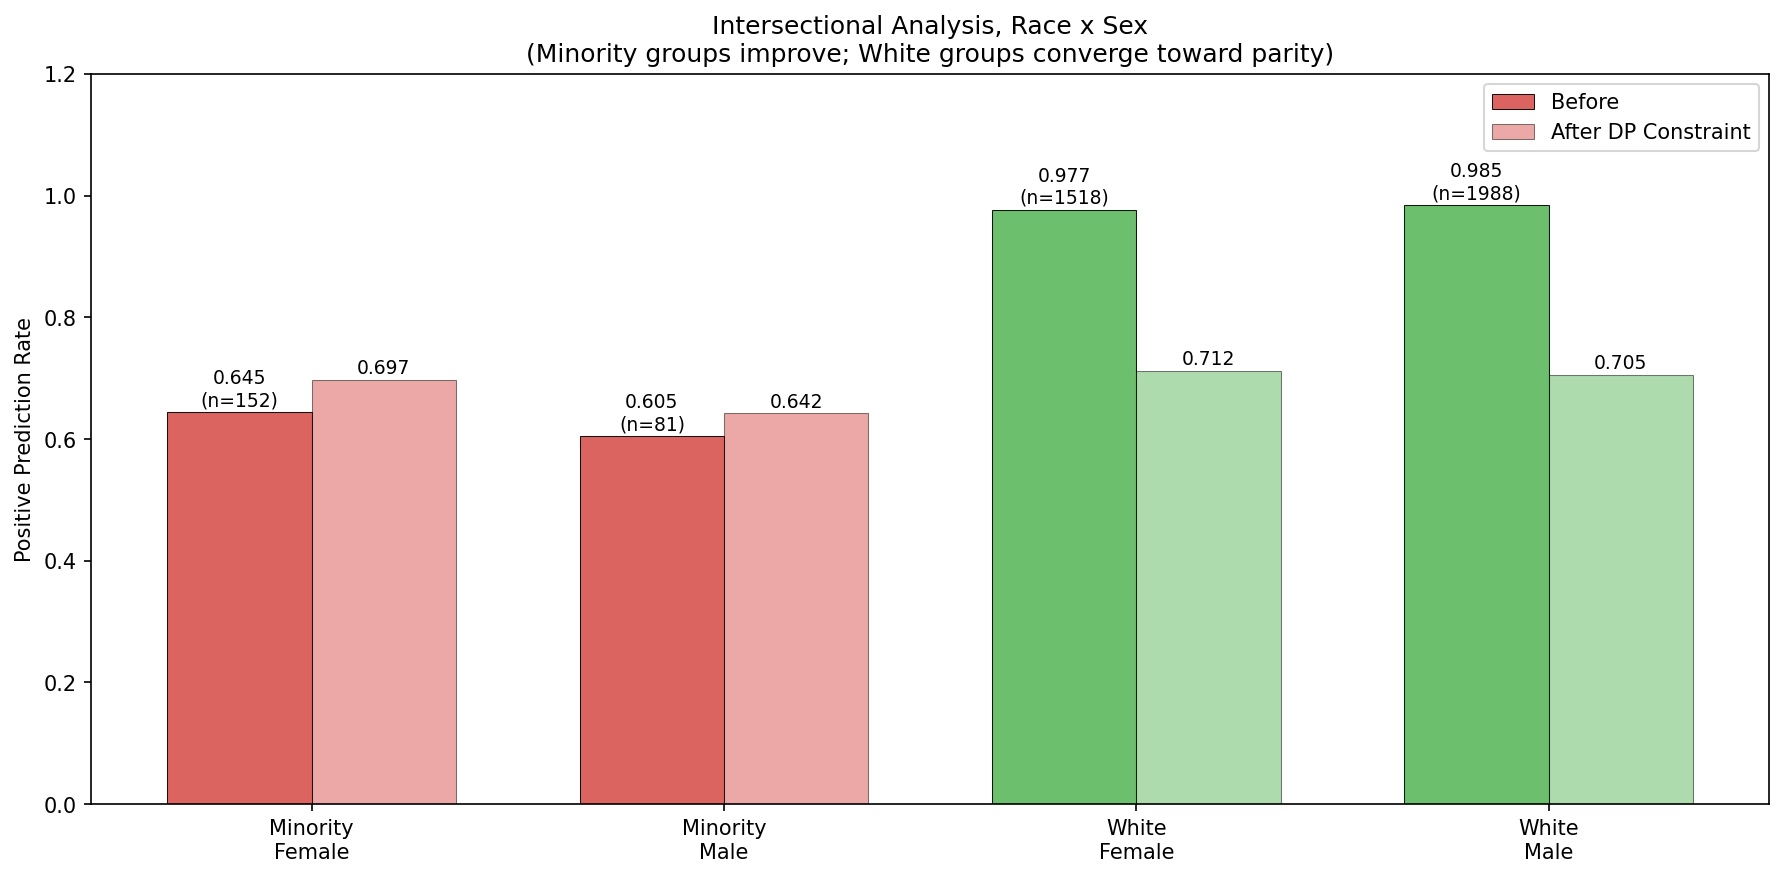

In [11]:
display(Image('figures/stage2/lawschool_intersectional_stage2.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.